# Eleições 2026 — 1º turno presidencial
### LADRI · Laboratório de Dados e Relações Internacionais (ASCES-UNITA)

Neste notebook vamos analisar o resultado do 1º turno da eleição presidencial de **4 de outubro de 2026**, usando dados oficiais do **Tribunal Superior Eleitoral (TSE)** e malhas territoriais do **IBGE**.

**Roteiro**
1. De onde vêm os dados: a API de resultados do TSE
2. Resultado nacional e estatística descritiva
3. Geografia do voto: mapas por estado e município
4. Recorte regional: Pernambuco e o Agreste
5. Relações Internacionais: o voto dos brasileiros no exterior
6. Comparação com 2022

> Este notebook usa as tabelas prontas em `data/processed/`, que estão no repositório. Os poucos arquivos brutos de que ele precisa (o resultado nacional do TSE e as malhas do IBGE) são lidos de `data/raw/` quando existem; se não existirem, são baixados direto das fontes oficiais. Para refazer todo o tratamento, rode `01_coleta.py` e `02_tratamento.py`.

In [1]:
import json
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

PROC = Path("data/processed")
RAW = Path("data/raw")
FIG = Path("figuras"); FIG.mkdir(exist_ok=True)

# Arquivos brutos usados aqui e suas fontes oficiais (baixados só se ainda não estiverem em data/raw/)
IBGE = "https://servicodados.ibge.gov.br/api/v3/malhas"
GEOJSON = "formato=application/vnd.geo+json"
FONTES_ONLINE = {
    "tse/br.json": "https://resultados.tse.jus.br/oficial/ele2026/6257/dados/br/br-c0001-e006257-u.json",
    "geo/br_uf.geojson": f"{IBGE}/paises/BR?intrarregiao=UF&qualidade=minima&{GEOJSON}",
    "geo/br_municipios.geojson": f"{IBGE}/paises/BR?intrarregiao=municipio&qualidade=minima&{GEOJSON}",
    "geo/pe_municipios.geojson": f"{IBGE}/estados/PE?intrarregiao=municipio&qualidade=intermediaria&{GEOJSON}",
    "geo/mundo.geojson": "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson",
}


def arquivo_bruto(nome):
    # Caminho local de um arquivo bruto; baixa da fonte oficial se ainda não existir.
    caminho = RAW / nome
    if not caminho.exists():
        caminho.parent.mkdir(parents=True, exist_ok=True)
        r = requests.get(FONTES_ONLINE[nome], timeout=180)
        r.raise_for_status()
        caminho.write_bytes(r.content)
    return caminho


# Cores fixas por candidato (as mesmas do painel)
COR = {"FLAVIO BOLSONARO": "#2a78d6", "LULA": "#e34948", "ESCRITOR AUGUSTO CURY": "#4a3aa7",
       "RENAN SANTOS": "#1baf7a", "RONALDO CAIADO": "#eda100"}
AZUL, VERMELHO, CINZA = "#2a78d6", "#e34948", "#a6aba7"

## 1. De onde vêm os dados

Na noite da eleição, o TSE publica os resultados em arquivos **JSON** num endereço público. Cada arquivo segue um padrão:

```
https://resultados.tse.jus.br/oficial/ele2026/6257/dados/{uf}/{uf}{municipio}-c0001-e006257-u.json
```

- `6257` é o código da eleição (1º turno federal de 2026)
- `c0001` é o cargo (Presidente)
- `{uf}{municipio}` identifica o local (`br` para o Brasil todo, `pe` para Pernambuco, `pe25313` para Recife…)

Vamos abrir o arquivo nacional (salvo em `data/raw/tse/br.json`; se ainda não estiver lá, é baixado agora):

In [2]:
with open(arquivo_bruto("tse/br.json"), encoding="utf-8") as f:
    br = json.load(f)

print("Eleitores aptos:", br["e"]["te"])
print("Comparecimento:", br["e"]["c"], f"({br['e']['pc']}%)")
print("Abstenção:     ", br["e"]["a"], f"({br['e']['pa']}%)")
print("Votos válidos: ", br["v"]["vv"])

Eleitores aptos: 158745502
Comparecimento: 125275835 (78,92%)
Abstenção:      33469244 (21,08%)
Votos válidos:  119300788


Os candidatos ficam "aninhados" dentro de agremiações (partidos/coligações). Com um laço simples transformamos isso em uma tabela:

In [3]:
linhas = []
for agr in br["carg"][0]["agr"]:
    for par in agr["par"]:
        for c in par["cand"]:
            linhas.append({"numero": c["n"], "candidato": c["nmu"], "partido": par["sg"],
                           "vice": c["vs"][0]["nmu"], "votos": int(c["vap"]), "situacao": c["st"]})

candidatos = pd.DataFrame(linhas).sort_values("votos", ascending=False)
candidatos["% válidos"] = 100 * candidatos.votos / candidatos.votos.sum()
candidatos

,numero,candidato,partido,vice,votos,situacao,% válidos
0,22,FLAVIO BOLSONARO,PL,ALFREDO GASPAR,56104503,2º turno,47.03
2,13,LULA,PT,GERALDO ALCKMIN,53879538,2º turno,45.16
6,70,ESCRITOR AUGUSTO CURY,AVANTE,JÚLIO DELGADO,3448569,Não eleito,2.89
10,14,RENAN SANTOS,MISSÃO,CORONEL MEDINA,2675887,Não eleito,2.24
1,55,RONALDO CAIADO,PSD,GILBERTO KASSAB,2605148,Não eleito,2.18
7,30,ZEMA,NOVO,EDUARDO GIRÃO,326488,Não eleito,0.27
8,80,SAMARA,UP,RAQUEL BRÍCIO,122911,Não eleito,0.10
5,16,HERTZ DIAS,PSTU,VANESSA PORTUGAL,43103,Não eleito,0.04
3,27,CLARIANA BARAO,DC,FABIANA TORQUATO,40043,Não eleito,0.03
4,21,EDMILSON COSTA,PCB,CLEUSA SANTOS,22693,Não eleito,0.02


## 2. Resultado nacional e estatística descritiva

Nenhum candidato alcançou mais de 50% dos votos válidos, então **Flávio Bolsonaro (PL)** e **Lula (PT)** disputam o 2º turno em 25 de outubro.

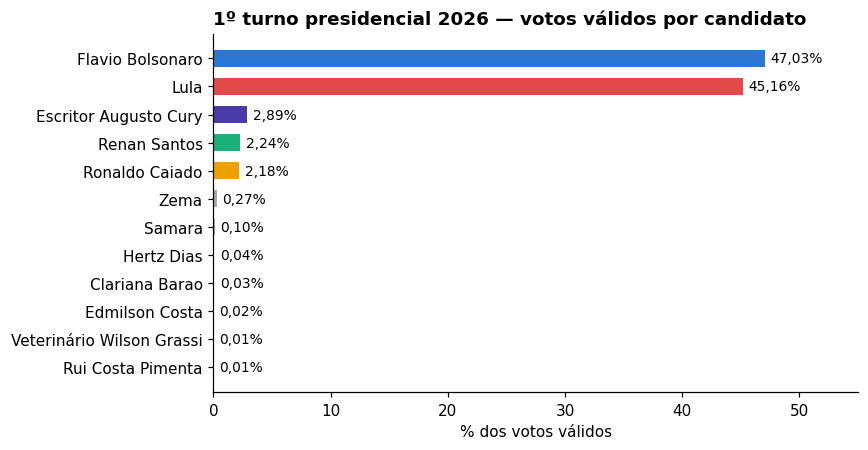

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.2))
d = candidatos.sort_values("% válidos")
ax.barh(d.candidato.str.title(), d["% válidos"], color=[COR.get(c, CINZA) for c in d.candidato], height=0.6)
for y, v in enumerate(d["% válidos"]):
    ax.text(v + 0.5, y, f"{v:.2f}%".replace(".", ","), va="center", fontsize=9)
ax.set_xlabel("% dos votos válidos"); ax.set_xlim(0, 55)
ax.set_title("1º turno presidencial 2026 — votos válidos por candidato", loc="left", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG / "01_candidatos.png", dpi=200); plt.show()

### A distribuição do voto entre os municípios

O resultado nacional é uma média ponderada. Quando olhamos os **5.571 municípios**, vemos uma distribuição muito dispersa. Vamos carregar a tabela de municípios:

In [5]:
mun = pd.read_csv(PROC / "municipios.csv", dtype={"cod_ibge": str, "cod_tse": str, "vencedor_num": str})
print(mun.shape)
mun[["nome_ibge", "uf", "regiao", "eleitores", "p_flavio", "p_lula", "p_abstencao", "vencedor"]].head()

(5571, 39)


,nome_ibge,uf,regiao,eleitores,p_flavio,p_lula,p_abstencao,vencedor
0,Acrelândia,AC,Norte,10207,76.24,19.36,21.08,FLAVIO BOLSONARO
1,Assis Brasil,AC,Norte,7294,59.30,36.50,21.24,FLAVIO BOLSONARO
2,Brasiléia,AC,Norte,19978,69.60,25.77,20.38,FLAVIO BOLSONARO
3,Bujari,AC,Norte,11152,66.57,28.82,22.37,FLAVIO BOLSONARO
4,Capixaba,AC,Norte,8170,67.12,27.50,20.28,FLAVIO BOLSONARO


In [6]:
# Medidas de tendência central e de dispersão do % de cada candidato por município
mun[["p_flavio", "p_lula", "p_abstencao"]].describe().T[["mean", "50%", "std", "min", "max"]] \
    .rename(columns={"mean": "média", "50%": "mediana", "std": "desvio-padrão"})

,média,mediana,desvio-padrão,min,max
p_flavio,45.32,47.58,17.71,8.60,87.02
p_lula,48.44,44.80,18.98,7.38,88.72
p_abstencao,20.72,20.59,4.05,7.31,40.09


**Atenção a uma armadilha clássica:** a *média dos municípios* não é o resultado nacional. Cada município conta "um" na média simples, mas São Paulo tem 9 milhões de eleitores e Serra da Saudade (MG) tem pouco mais de mil. Por isso usamos médias **ponderadas** pelo número de votos válidos:

In [7]:
media_simples = mun.p_lula.mean()
media_ponderada = (mun.p_lula * mun.validos).sum() / mun.validos.sum()
print(f"Lula — média simples dos municípios: {media_simples:.2f}%")
print(f"Lula — média ponderada pelos votos:  {media_ponderada:.2f}%  (≈ resultado nacional sem o exterior)")
print()
print("Municípios vencidos:", mun.vencedor.value_counts().to_dict())

Lula — média simples dos municípios: 48.44%
Lula — média ponderada pelos votos:  45.16%  (≈ resultado nacional sem o exterior)

Municípios vencidos: {'FLAVIO BOLSONARO': 2908, 'LULA': 2663}


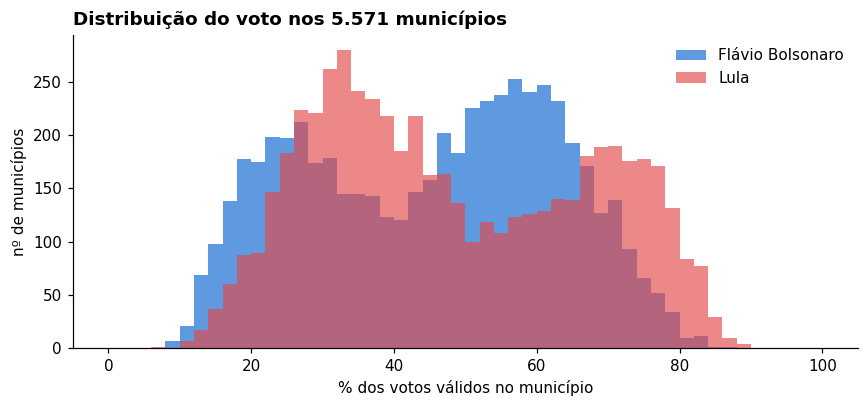

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.8))
bins = range(0, 101, 2)
ax.hist(mun.p_flavio, bins=bins, color=AZUL, alpha=.75, label="Flávio Bolsonaro")
ax.hist(mun.p_lula, bins=bins, color=VERMELHO, alpha=.65, label="Lula")
ax.set_xlabel("% dos votos válidos no município"); ax.set_ylabel("nº de municípios")
ax.set_title("Distribuição do voto nos 5.571 municípios", loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(FIG / "02_distribuicao.png", dpi=200); plt.show()

A distribuição é **bimodal**: há muitos municípios onde Lula tem mais de 70% e muitos onde Flávio tem mais de 60%. Isso indica um eleitorado regionalmente polarizado. Vejamos por região:

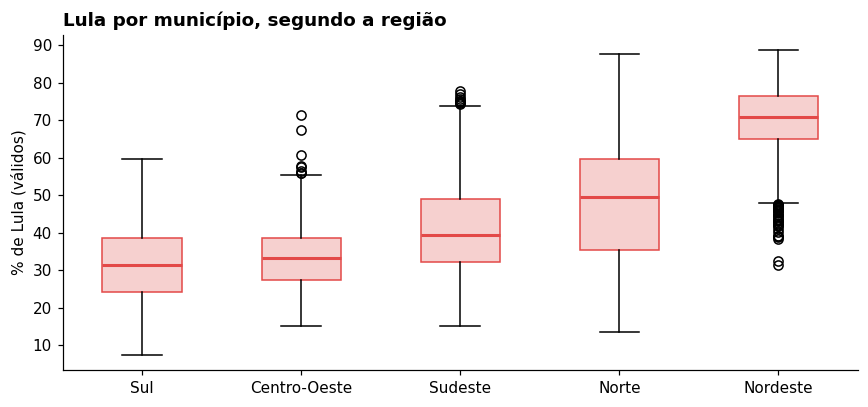

,eleitores,% Flávio,% Lula
regiao,,,
Sul,22870853,60.08,31.28
Centro-Oeste,12001141,56.51,32.62
Sudeste,66344562,51.36,39.68
Norte,13101175,49.15,44.65
Nordeste,43511237,30.85,63.77


In [9]:
ordem = ["Sul", "Centro-Oeste", "Sudeste", "Norte", "Nordeste"]
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.boxplot([mun.loc[mun.regiao == r, "p_lula"] for r in ordem], tick_labels=ordem, widths=.5,
           patch_artist=True, boxprops=dict(facecolor="#f6d0cf", edgecolor=VERMELHO), medianprops=dict(color=VERMELHO, lw=2))
ax.set_ylabel("% de Lula (válidos)")
ax.set_title("Lula por município, segundo a região", loc="left", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG / "03_boxplot_regioes.png", dpi=200); plt.show()

regioes = mun.groupby("regiao")[["eleitores", "validos", "v_flavio", "v_lula"]].sum()
regioes["% Flávio"] = 100 * regioes.v_flavio / regioes.validos
regioes["% Lula"] = 100 * regioes.v_lula / regioes.validos
regioes.loc[ordem, ["eleitores", "% Flávio", "% Lula"]]

## 3. Geografia do voto: mapas

Para fazer mapas, juntamos a tabela de resultados com a **malha de municípios do IBGE** usando o código IBGE de 7 dígitos. Essa operação (o *join*) é o coração de qualquer análise georreferenciada.

In [10]:
malha = gpd.read_file(arquivo_bruto("geo/br_municipios.geojson")).rename(columns={"codarea": "cod_ibge"})
malha_uf = gpd.read_file(arquivo_bruto("geo/br_uf.geojson"))
geo = malha.merge(mun, on="cod_ibge", how="left")
print("Municípios na malha:", len(malha), "| sem resultado após o join:", geo.vencedor.isna().sum())

Municípios na malha: 5570 | sem resultado após o join: 0


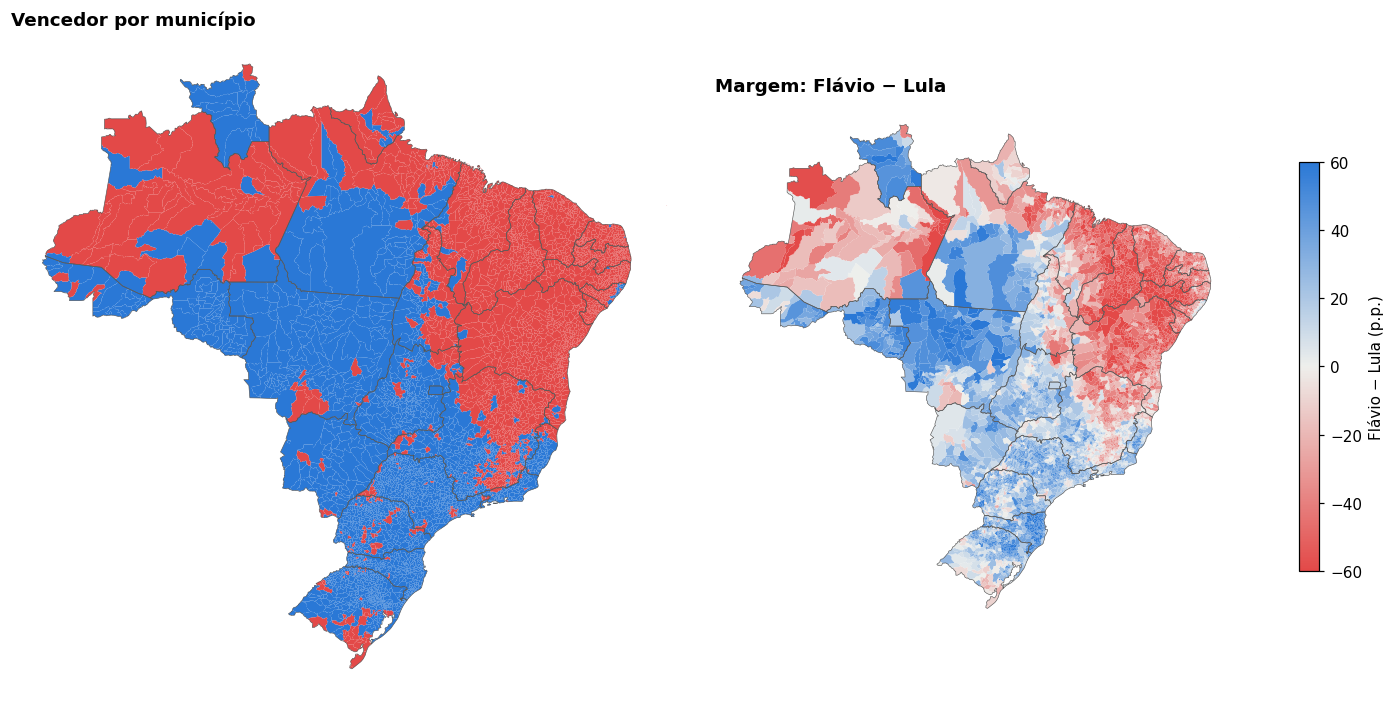

In [11]:
geo["margem"] = geo.p_flavio - geo.p_lula   # positivo = Flávio à frente
cmap = mcolors.LinearSegmentedColormap.from_list("margem", [VERMELHO, "#eeefec", AZUL])

fig, axs = plt.subplots(1, 2, figsize=(13, 6.5))
geo.plot(ax=axs[0], color=geo.vencedor.map({"FLAVIO BOLSONARO": AZUL, "LULA": VERMELHO}), linewidth=0)
axs[0].set_title("Vencedor por município", loc="left", fontweight="bold")
geo.plot(ax=axs[1], column="margem", cmap=cmap, vmin=-60, vmax=60, linewidth=0, legend=True,
         legend_kwds={"label": "Flávio − Lula (p.p.)", "shrink": .6})
axs[1].set_title("Margem: Flávio − Lula", loc="left", fontweight="bold")
for ax in axs:
    malha_uf.boundary.plot(ax=ax, color="#555", linewidth=.4); ax.set_axis_off()
plt.tight_layout(); plt.savefig(FIG / "04_mapa_brasil.png", dpi=200); plt.show()

O mapa "Vencedor" exagera o tamanho da vitória de Flávio, porque áreas grandes e pouco povoadas (Centro-Oeste, Norte) ocupam muito espaço. O mapa de **margem** é mais honesto: mostra também *quão* apertada foi a disputa em cada lugar.

Outro indicador interessante é a **abstenção**:

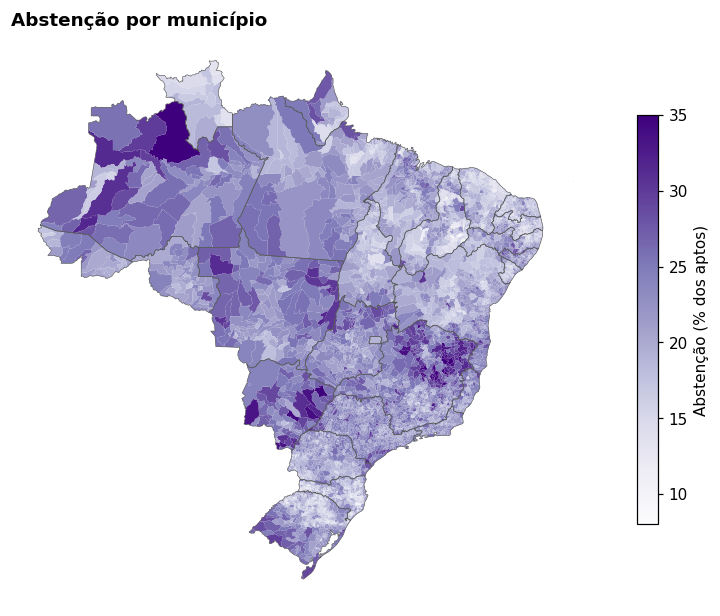

In [12]:
fig, ax = plt.subplots(figsize=(7, 6.5))
geo.plot(ax=ax, column="p_abstencao", cmap="Purples", vmin=8, vmax=35, linewidth=0, legend=True,
         legend_kwds={"label": "Abstenção (% dos aptos)", "shrink": .6})
malha_uf.boundary.plot(ax=ax, color="#555", linewidth=.4); ax.set_axis_off()
ax.set_title("Abstenção por município", loc="left", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG / "05_mapa_abstencao.png", dpi=200); plt.show()

## 4. Pernambuco e o Agreste

In [13]:
pe = mun[mun.uf == "PE"].copy()
ufs = pd.read_csv(PROC / "ufs.csv")
print(ufs.loc[ufs.uf == "PE", ["p_flavio", "p_lula", "p_abstencao"]].to_string(index=False))

meso = pe.groupby("mesorregiao")[["eleitores", "validos", "v_flavio", "v_lula"]].sum()
meso["% Flávio"] = 100 * meso.v_flavio / meso.validos
meso["% Lula"] = 100 * meso.v_lula / meso.validos
meso[["eleitores", "% Flávio", "% Lula"]].sort_values("% Lula")

 p_flavio  p_lula  p_abstencao
    31.03   63.45        18.17


,eleitores,% Flávio,% Lula
mesorregiao,,,
Metropolitana de Recife,3019222,36.81,56.94
Mata Pernambucana,1029936,31.24,63.94
Agreste Pernambucano,1849854,28.30,66.64
São Francisco Pernambucano,495523,25.60,68.58
Sertão Pernambucano,828915,18.36,77.20


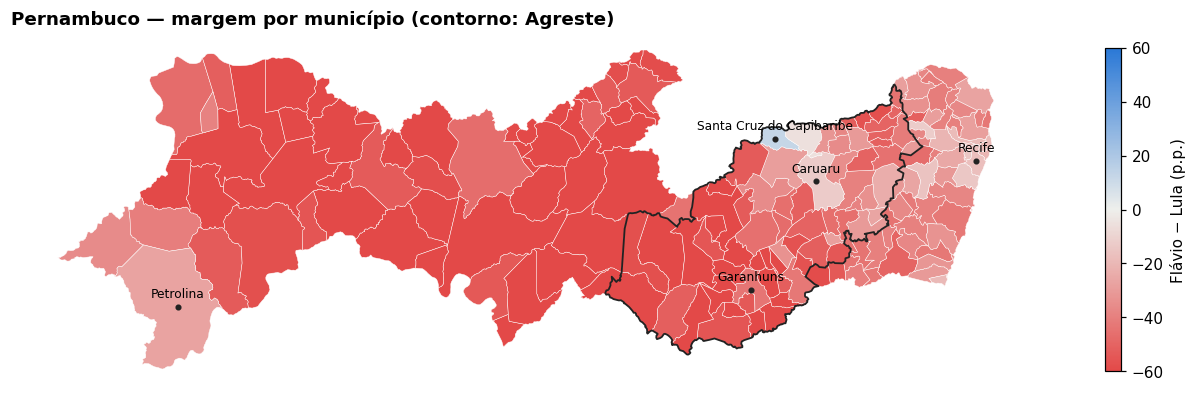

In [14]:
malha_pe = gpd.read_file(arquivo_bruto("geo/pe_municipios.geojson")).rename(columns={"codarea": "cod_ibge"}).merge(pe, on="cod_ibge")
malha_pe = malha_pe[malha_pe.nome_ibge != "Fernando de Noronha"]  # arquipélago distante distorce a escala do mapa
malha_pe["margem"] = malha_pe.p_flavio - malha_pe.p_lula
agreste = malha_pe[malha_pe.mesorregiao == "Agreste Pernambucano"].dissolve()

fig, ax = plt.subplots(figsize=(12, 4.5))
malha_pe.plot(ax=ax, column="margem", cmap=cmap, vmin=-60, vmax=60, edgecolor="white", linewidth=.3, legend=True,
              legend_kwds={"label": "Flávio − Lula (p.p.)", "shrink": .7})
agreste.boundary.plot(ax=ax, color="#222", linewidth=1.2)
for nome in ["Caruaru", "Recife", "Santa Cruz do Capibaribe", "Petrolina", "Garanhuns"]:
    p = malha_pe.loc[malha_pe.nome_ibge == nome].geometry.representative_point().iloc[0]
    ax.annotate(nome, (p.x, p.y), fontsize=8, ha="center", xytext=(0, 6), textcoords="offset points")
    ax.plot(p.x, p.y, "o", ms=3, color="#222")
ax.set_axis_off(); ax.set_title("Pernambuco — margem por município (contorno: Agreste)", loc="left", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG / "06_mapa_pe.png", dpi=200); plt.show()

In [15]:
# Região imediata de Caruaru (divisão regional do IBGE de 2017)
car = pe[pe.regiao_imediata == "Caruaru"].sort_values("eleitores", ascending=False)
car[["nome_ibge", "eleitores", "p_flavio", "p_lula", "p_abstencao"]].rename(columns={"nome_ibge": "município"})

,município,eleitores,p_flavio,p_lula,p_abstencao
3227,Caruaru,255270,40.23,53.32,14.94
3253,Gravatá,67863,35.17,58.93,17.78
3326,Santa Cruz do Capibaribe,66108,52.71,40.11,13.65
3203,Bezerros,48313,27.73,67.22,16.95
3209,Brejo da Madre de Deus,36268,32.62,61.81,21.63
3355,Toritama,35207,44.81,50.20,14.28
3339,São Caitano,30888,22.06,73.29,15.26
3207,Bonito,30694,32.06,62.77,19.73
3351,Taquaritinga do Norte,22236,44.88,50.37,14.80
3316,Riacho das Almas,20962,30.07,65.20,13.03


Note como o **polo de confecções** (Santa Cruz do Capibaribe, Toritama, Taquaritinga do Norte) vota de forma diferente do restante do Agreste. Que características econômicas e sociais poderiam explicar isso?

## 5. Relações Internacionais: os brasileiros no exterior

Brasileiros que moram fora votam para presidente em seções instaladas em embaixadas e consulados. O TSE informa a **cidade** da seção; nós atribuímos o país e o continente (arquivo `exterior_paises.py`).

In [16]:
paises = pd.read_csv(PROC / "exterior_paises.csv")
ext = ufs[ufs.uf == "ZZ"].iloc[0]
print(f"Eleitores no exterior: {ext.eleitores:,.0f} | comparecimento: {ext.comparecimento:,.0f} | abstenção: {ext.p_abstencao:.1f}%")
print(f"Flávio: {ext.p_flavio:.2f}% | Lula: {ext.p_lula:.2f}%")
paises[["pais", "continente", "eleitores", "p_abstencao", "p_flavio", "p_lula", "p_lula22"]].head(15)

Eleitores no exterior: 916,534 | comparecimento: 341,766 | abstenção: 62.7%
Flávio: 43.49% | Lula: 47.57%


,pais,continente,eleitores,p_abstencao,p_flavio,p_lula,p_lula22
0,Estados Unidos,América do Norte,265022,71.55,61.10,31.68,31.44
1,Portugal,Europa,134374,61.54,38.57,52.45,60.39
2,Japão,Ásia,88293,58.52,71.76,15.27,13.49
3,Canadá,América do Norte,46345,51.57,32.52,57.75,54.49
4,Reino Unido,Europa,41895,63.02,35.42,57.03,55.18
5,Alemanha,Europa,41401,53.51,18.79,71.93,69.44
6,Espanha,Europa,40718,70.48,28.78,62.63,60.27
7,Itália,Europa,38747,68.85,37.83,53.02,52.02
8,França,Europa,29617,61.46,15.68,78.23,77.60
9,Suíça,Europa,26982,58.35,41.69,47.86,45.80


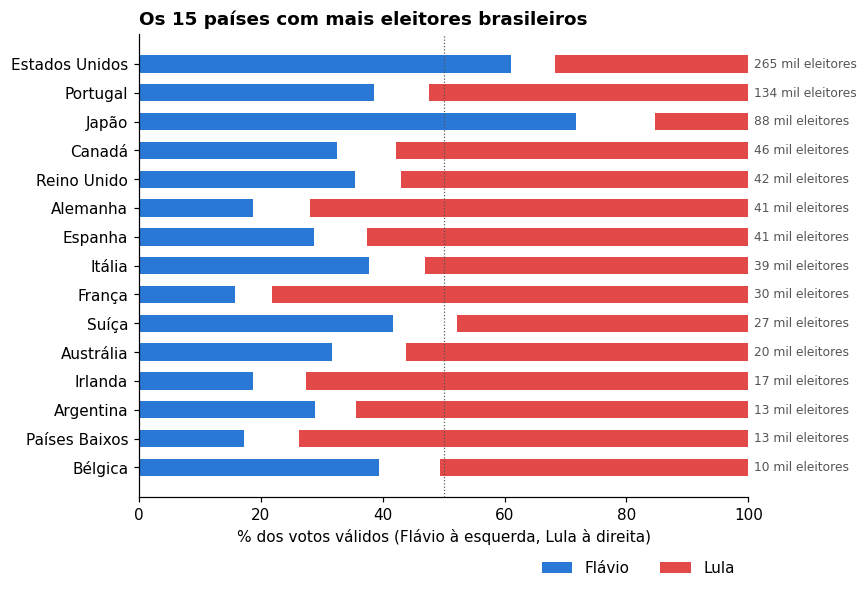

In [17]:
top = paises.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top.pais, top.p_flavio, color=AZUL, height=.6, label="Flávio")
ax.barh(top.pais, top.p_lula, left=100 - top.p_lula, color=VERMELHO, height=.6, label="Lula")
for y, (e, f, l) in enumerate(zip(top.eleitores, top.p_flavio, top.p_lula)):
    ax.text(101, y, f"{e/1000:.0f} mil eleitores", va="center", fontsize=8, color="#555")
ax.axvline(50, color="#555", lw=.8, ls=":")
ax.set_xlim(0, 100); ax.set_xlabel("% dos votos válidos (Flávio à esquerda, Lula à direita)")
ax.set_title("Os 15 países com mais eleitores brasileiros", loc="left", fontweight="bold")
ax.legend(frameon=False, loc="lower right", bbox_to_anchor=(1, -0.2), ncol=2)
plt.tight_layout(); plt.savefig(FIG / "07_exterior_paises.png", dpi=200, bbox_inches="tight"); plt.show()

In [18]:
cont = paises.groupby("continente")[["eleitores", "comparecimento", "validos", "v_flavio", "v_lula"]].sum()
cont["% abstenção"] = 100 * (1 - cont.comparecimento / cont.eleitores)
cont["% Flávio"] = 100 * cont.v_flavio / cont.validos
cont["% Lula"] = 100 * cont.v_lula / cont.validos
cont.sort_values("eleitores", ascending=False)[["eleitores", "% abstenção", "% Flávio", "% Lula"]]

,eleitores,% abstenção,% Flávio,% Lula
continente,,,,
Europa,413025,60.54,30.86,60.27
América do Norte,315325,68.56,54.49,37.71
Ásia,93810,58.88,69.97,17.07
América do Sul,42456,52.53,53.11,39.93
Oceania,23392,62.65,31.24,56.68
Oriente Médio,21176,57.44,31.32,61.41
América Central e Caribe,3686,54.15,50.03,38.74
África,3664,60.13,41.41,50.64


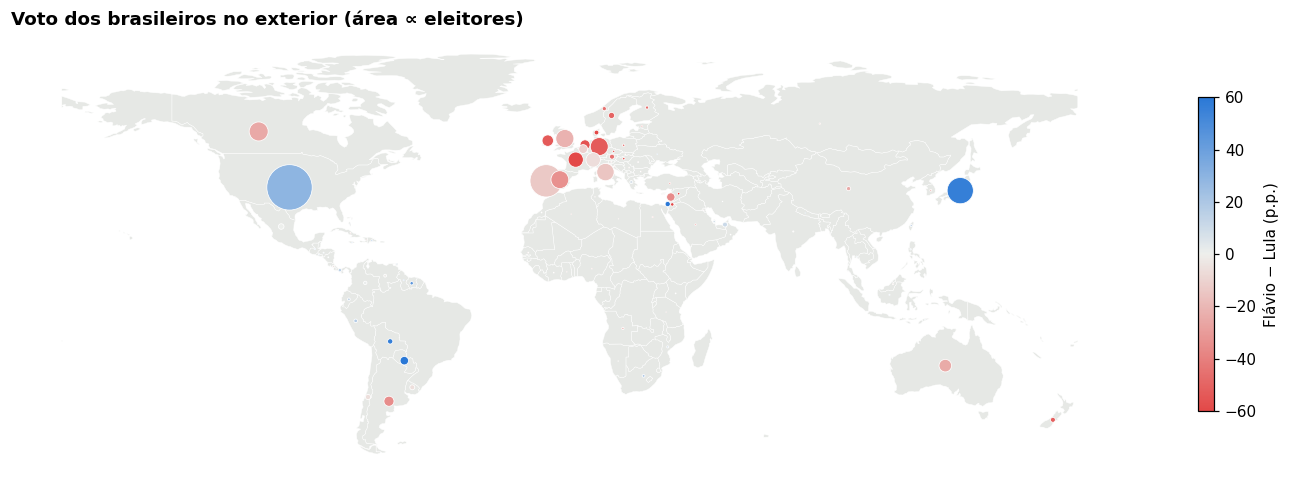

Países pequenos não desenhados neste mapa simplificado: ['ATG', 'BHR', 'BRB', 'CPV', 'GUF', 'LCA', 'PSE', 'SGP', 'STP']


In [19]:
# Mapa-múndi com bolhas proporcionais ao número de eleitores
mundo = gpd.read_file(arquivo_bruto("geo/mundo.geojson"))
mundo = mundo[mundo.ADM0_A3 != "ATA"]
# Ponto de cada país no seu maior polígono (evita, por exemplo, a bolha da Noruega cair em Svalbard)
maior = lambda g: max(g.geoms, key=lambda p: p.area) if g.geom_type == "MultiPolygon" else g
pts = mundo.assign(geometry=mundo.geometry.map(lambda g: maior(g).representative_point()))[["ADM0_A3", "geometry"]].rename(columns={"ADM0_A3": "iso3"})
bolhas = pts.merge(paises, on="iso3")
bolhas["margem"] = bolhas.p_flavio - bolhas.p_lula

fig, ax = plt.subplots(figsize=(13, 6))
mundo.plot(ax=ax, color="#e6e8e5", edgecolor="white", linewidth=.3)
bolhas.sort_values("eleitores", ascending=False).plot(ax=ax, column="margem", cmap=cmap, vmin=-60, vmax=60,
    markersize=bolhas.sort_values("eleitores", ascending=False).eleitores / 300, edgecolor="white", linewidth=.5, legend=True,
    legend_kwds={"label": "Flávio − Lula (p.p.)", "shrink": .5})
ax.set_axis_off(); ax.set_title("Voto dos brasileiros no exterior (área ∝ eleitores)", loc="left", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG / "08_mapa_mundo.png", dpi=200); plt.show()
print("Países pequenos não desenhados neste mapa simplificado:", sorted(set(paises.iso3) - set(bolhas.iso3)))

## 6. O que mudou desde 2022?

Usamos o arquivo de dados abertos do TSE de 2022 (`votacao_candidato_munzona_2022.zip`). Como o candidato do PL mudou (Jair → Flávio Bolsonaro), comparamos **campos políticos**, não pessoas.

Correlação entre % de Lula em 2022 e 2026 (municípios): r = 0.985
Municípios onde Lula caiu: 5468 de 5570


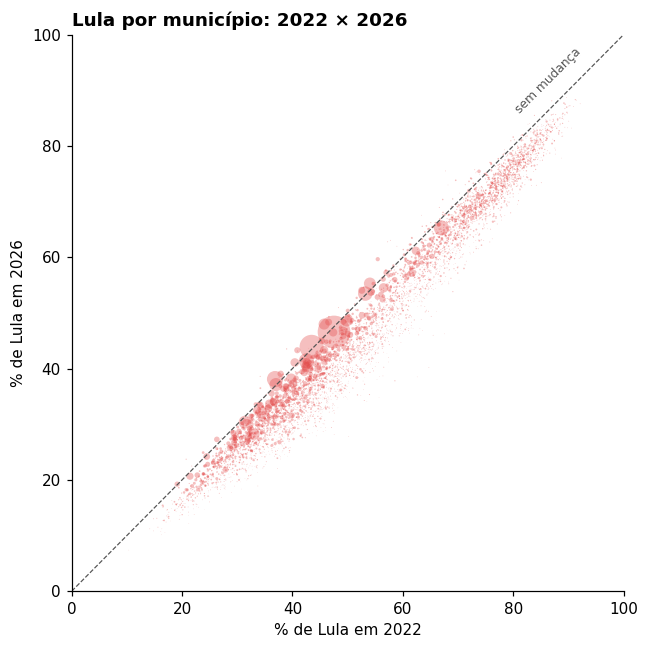

In [20]:
comp = mun.dropna(subset=["p_lula22"]).copy()
comp["d_lula"] = comp.p_lula - comp.p_lula22
print(f"Correlação entre % de Lula em 2022 e 2026 (municípios): r = {comp.p_lula.corr(comp.p_lula22):.3f}")
print(f"Municípios onde Lula caiu: {(comp.d_lula < 0).sum()} de {len(comp)}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(comp.p_lula22, comp.p_lula, s=comp.eleitores / 20000, alpha=.35, color=VERMELHO, edgecolor="none")
ax.plot([0, 100], [0, 100], color="#555", lw=.8, ls="--")
ax.text(80, 86, "sem mudança", rotation=45, fontsize=8, color="#555")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel("% de Lula em 2022"); ax.set_ylabel("% de Lula em 2026")
ax.set_title("Lula por município: 2022 × 2026", loc="left", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG / "09_dispersao_2022_2026.png", dpi=200); plt.show()

Quase todos os pontos estão um pouco **abaixo** da diagonal: Lula perdeu espaço de forma generalizada, mas a correlação altíssima mostra que a **geografia do voto quase não mudou** — os lugares que eram lulistas continuam lulistas.

In [21]:
ufs_c = ufs[ufs.uf != "ZZ"].assign(d_lula=lambda d: d.p_lula - d.p_lula22).sort_values("d_lula")
ufs_c[["uf", "p_lula22", "p_lula", "d_lula", "p_bolsonaro22", "p_flavio"]].rename(columns={
    "p_lula22": "Lula 2022", "p_lula": "Lula 2026", "d_lula": "variação (p.p.)", "p_bolsonaro22": "Jair 2022", "p_flavio": "Flávio 2026"})

,uf,Lula 2022,Lula 2026,variação (p.p.),Jair 2022,Flávio 2026
9,GO,39.52,31.06,-8.46,52.16,53.60
27,TO,50.40,43.42,-6.97,44.00,50.44
21,RS,42.28,35.73,-6.56,48.89,55.64
11,MT,34.39,29.18,-5.21,59.84,65.15
13,MG,48.29,43.33,-4.96,43.60,48.24
10,MA,68.84,63.99,-4.85,26.02,30.89
14,PR,35.99,31.20,-4.79,55.26,59.91
24,SC,29.54,25.04,-4.49,62.21,66.65
12,MS,39.04,34.68,-4.36,52.70,58.60
4,BA,69.73,66.17,-3.55,24.31,28.53


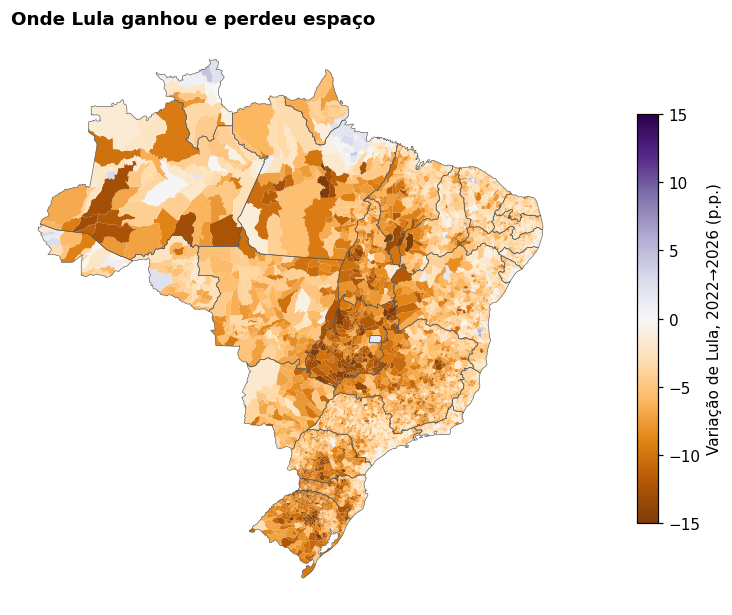

In [22]:
geo["d_lula"] = geo.p_lula - geo.p_lula22
fig, ax = plt.subplots(figsize=(7, 6.5))
geo.plot(ax=ax, column="d_lula", cmap="PuOr", vmin=-15, vmax=15, linewidth=0, legend=True,
         legend_kwds={"label": "Variação de Lula, 2022→2026 (p.p.)", "shrink": .6})
malha_uf.boundary.plot(ax=ax, color="#555", linewidth=.4); ax.set_axis_off()
ax.set_title("Onde Lula ganhou e perdeu espaço", loc="left", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG / "10_mapa_variacao.png", dpi=200); plt.show()

---
*Fontes: TSE (resultados 2026 e dados abertos 2022), IBGE (malhas e divisão regional), Natural Earth. Elaboração: LADRI/ASCES-UNITA.*

*Este notebook e a plataforma de análise foram desenvolvidos pelo LADRI com o auxílio do Claude, assistente de inteligência artificial da Anthropic. A revisão do conteúdo foi feita pela equipe do LADRI, e os totais foram conferidos com os números oficiais do TSE. Repositório: https://github.com/ladriasces/Elei-es-2026---LADRI*